# Project Objective

### The goal of this project is to analyze Netflix's catalog to identify trends in content type, release patterns, ratings, and geographic distribution.

In [2]:
# Importing libraries
import os
import pandas as pd
import matplotlib.pyplot as plt

# Loading and Inspecting Data

In [3]:
# Loading the dataset
df = pd.read_csv('netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [4]:
# Inspecting the dataset
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


(8807, 12)

In [5]:
# Checking missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Cleaning Data Section|

In [6]:
# Ensure we are working with a clean copy
df = df.copy()

# Fixing the rating / duration issue
mask = df['rating'].str.contains('min', na = False)
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = pd.NA

df['rating'].value_counts(dropna = False)
df['duration'].value_counts(dropna = False)

# Drop rows where country is missing to keep country analysis accurate
df = df.dropna(subset=['country'])

# Fixing date variable
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df['year_added'] = df['date_added'].dt.year

# Preserving as much data as possible
df['rating'] = df['rating'].fillna('Unknown')
df = df.dropna(subset=['date_added', 'duration'])

# Creating a new variable to use for the duration variable
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float) # Creating Variable for number only without descriptions
df['duration_type'] = df['duration'].str.extract('(min|Season|Seasons)') # Creating variable for types of duration descriptions
df['duration_type'] = df['duration_type'].replace({
   'Season' : 'Seasons'
}) # Making labels consistent
df['movie_minutes'] = df['duration_int'].where(df['duration_type'] == 'min' ) # Creating variable for movie minutes
df['tv_seasons'] = df['duration_int'].where(df['duration_type'] == 'Seasons' ) # Creating variable for tv seasons


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7882 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        7882 non-null   object        
 1   type           7882 non-null   object        
 2   title          7882 non-null   object        
 3   director       5746 non-null   object        
 4   cast           7219 non-null   object        
 5   country        7882 non-null   object        
 6   date_added     7882 non-null   datetime64[ns]
 7   release_year   7882 non-null   int64         
 8   rating         7882 non-null   object        
 9   duration       7882 non-null   object        
 10  listed_in      7882 non-null   object        
 11  description    7882 non-null   object        
 12  year_added     7882 non-null   float64       
 13  duration_int   7882 non-null   float64       
 14  duration_type  7882 non-null   object        
 15  movie_minutes  5691 non-nu

# Analysis Section

In [8]:
# Prepare country data for analysis
df['country_list'] = df['country'].str.split(', ')
countries_exploded = df.explode('country_list')

In [9]:
#Movies vs TV shows
df['type'].value_counts()

type
Movie      5691
TV Show    2191
Name: count, dtype: int64

In [10]:
# Top 10 countries producing content (exploded by country)
countries_exploded['country_list'].value_counts().head(10)

country_list
United States     3642
India             1045
United Kingdom     785
Canada             432
France             389
Japan              314
Spain              228
South Korea        226
Germany            225
Mexico             169
Name: count, dtype: int64

In [11]:
# Most common ratings
df['rating'].value_counts()

rating
TV-MA       2908
TV-14       1904
R            788
TV-PG        748
PG-13        482
PG           281
TV-Y7        232
TV-Y         221
TV-G         183
NR            78
G             41
Unknown        6
TV-Y7-FV       4
NC-17          3
UR             3
Name: count, dtype: int64

In [12]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
4    International TV Shows, Romantic TV Shows, TV ...
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
Name: listed_in, dtype: object

In [13]:
# Split genres into list
df['genre_list'] = df['listed_in'].str.split(', ')
df[['genre_list', 'listed_in']].head()

,genre_list,listed_in
0,[Documentaries],Documentaries
1,"[International TV Shows, TV Dramas, TV Mysteries]","International TV Shows, TV Dramas, TV Mysteries"
4,"[International TV Shows, Romantic TV Shows, TV...","International TV Shows, Romantic TV Shows, TV ..."
7,"[Dramas, Independent Movies, International Mov...","Dramas, Independent Movies, International Movies"
8,"[British TV Shows, Reality TV]","British TV Shows, Reality TV"


In [14]:
# Turning one row with 3 genres into 3 rows, one for each genre
genres_exploded = df.explode('genre_list')
genres_exploded['genre_list'].value_counts().head(10)

genre_list
International Movies      2543
Dramas                    2317
Comedies                  1580
International TV Shows    1107
Action & Adventure         817
Documentaries              794
Independent Movies         745
TV Dramas                  639
Romantic Movies            588
Thrillers                  549
Name: count, dtype: int64

## Visuals 

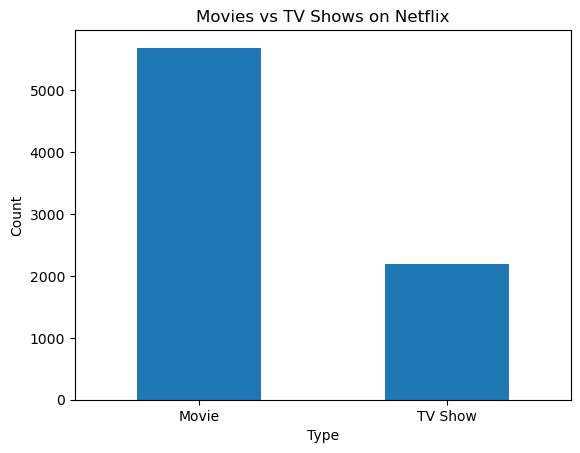

In [15]:
# Movies vs TV shows

df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#### Netflix’s catalog is heavily skewed toward movies, which may reflect a strategy focused on rapidly expanding its content library. Compared to multi-season TV shows, movies typically require less long-term commitment, allowing Netflix to scale its catalog more quickly and experiment with a wider range of content.

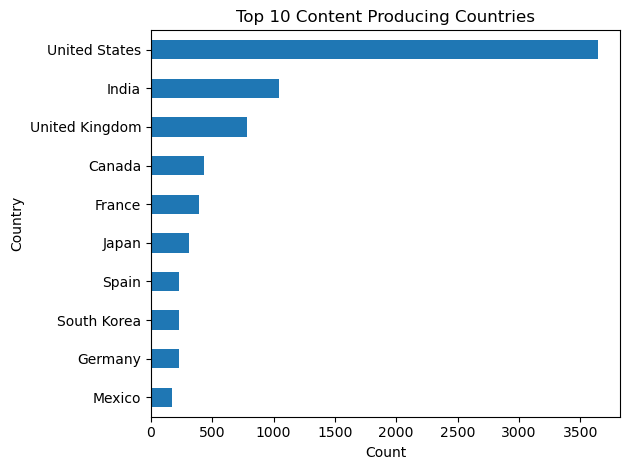

In [16]:
# Top Countries producing content

countries_exploded['country_list'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Count')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### While the U.S. produces the most content, the presence of countries like India and South Korea highlights Netflix’s investment in international markets, likely driven by global subscriber growth and localization strategies.

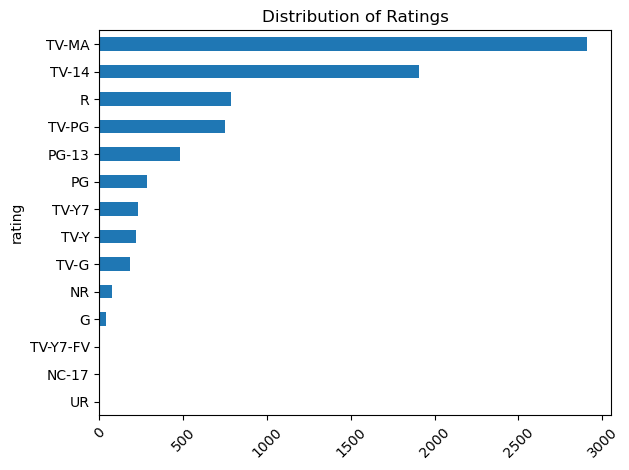

In [17]:
# Ratings Distribution
df[df['rating'] != 'Unknown']['rating'].value_counts().plot(kind='barh')
plt.title('Distribution of Ratings')
plt.xticks(rotation=45)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# TV-MA is the most produced rating on Netflix

#### The distribution of ratings is dominated by mature content, suggesting Netflix focuses more on general-audience and adult programming. This may reflect broader appeal and flexibility in storytelling, as mature-rated content can target a wider range of themes compared to child-focused programming.

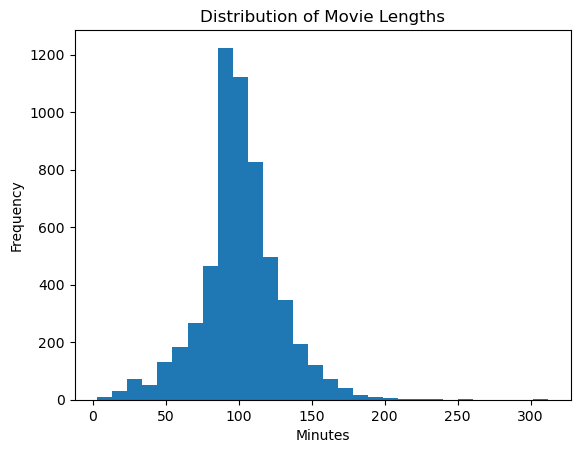

In [18]:
# Movie Length Distribution
df['movie_minutes'].dropna().plot(kind='hist', bins=30)
plt.title('Distribution of Movie Lengths')
plt.xlabel('Minutes')
plt.show()

# Most movies cluster around 90-120 minutes

#### The distribution shows a tight cluster of films being made around 90 to 120 minutes long with a slight skew to the right. This could suggest an industry standard on movie length and the rare amount of films being 200 to 300 minutes long may reflect a specific type of catalog composition.

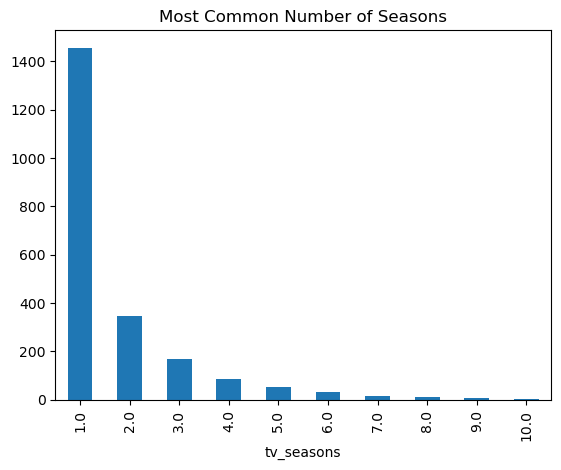

In [19]:
# TV Seasons distribution
df['tv_seasons'].dropna().value_counts().head(10).plot(kind='bar')
plt.title('Most Common Number of Seasons')
plt.show()

# Most TV shows only have 1-2 seasons

#### This shows a large majority of shows containing 1 season, with a sharp drop off after 1 season, and the distribution is heavily right-skewed. This may reflect shorter show lifecycles or a catalog with many limited-run series, but additional data would be needed to confirm this.

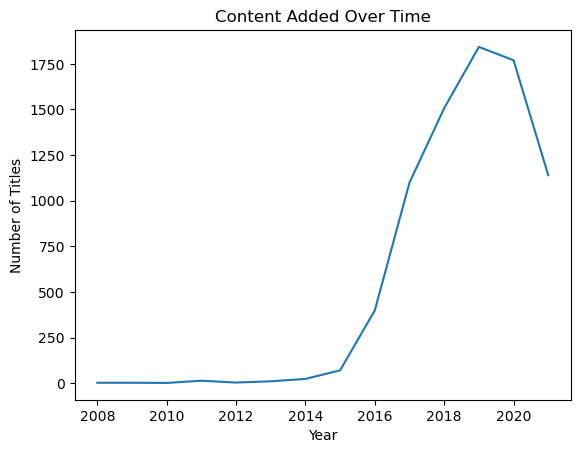

In [20]:
# Time trend
df['year_added'].value_counts().sort_index().plot(kind = 'line')
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

# Netflix saw rapid content growth after ~2015

#### This shows a rapid content growth roughly around 2015, peaking around 2019 and declining afterwards, which could suggest an aggressive period of catalog expansion followed by a slowdown.

In [21]:
# Average movie length by rating
df.groupby('rating')['movie_minutes'].mean().sort_values(ascending = False)

# Higher-rated (mature) content generally tend to be longer

rating
NC-17       125.000000
TV-14       110.418516
PG-13       108.587137
R           106.650572
UR          106.333333
PG           98.558719
TV-MA        96.339397
TV-PG        95.053571
NR           94.533333
G            90.268293
Unknown      84.750000
TV-G         79.477064
TV-Y7-FV     68.500000
TV-Y7        63.385542
TV-Y         52.547619
Name: movie_minutes, dtype: float64

#### This comparison between ratings shows that films with higher ratings tend to have longer runtimes than lower rated films, which may reflect differences in content structure or target audience.

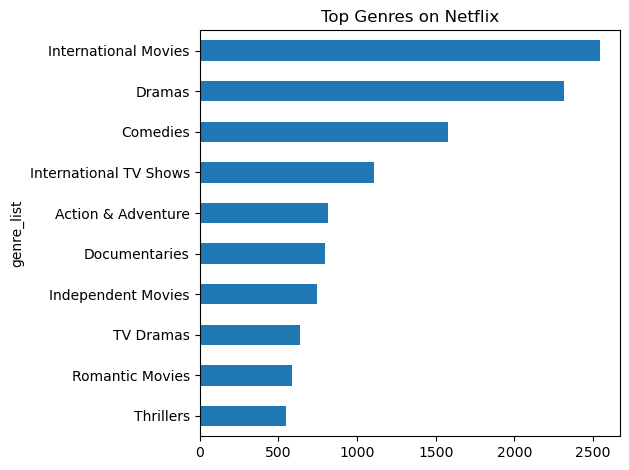

In [168]:
# Top Genres
genres_exploded['genre_list'].value_counts().head(10).plot(kind = 'barh')
plt.title('Top Genres on Netflix')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Drama and International content dominate Netflix

#### This distribution shows that International Movies and Dramas dominate the catalog, with a noticeable drop-off across other genres, indicating an uneven genre distribution and a stronger representation of specific content categories.

#### When filtering for countries with at least 50 movies, the average runtimes fall within a relatively narrow range of roughly 100 to 125 minutes, suggesting that film length is fairly consistent globally rather than region-specific.

# Conclusion & Summary

#### This analysis explored patterns in Netflix’s content catalog, focusing on movie length, TV seasons, and overall content trends. The findings indicate a potential standardization in movie runtimes, shorter lifecycles for TV shows, and a period of rapid catalog expansion. Together, these patterns suggest a catalog that emphasizes consistent content formats and frequent additions over time. However, this analysis is limited to the available dataset and would require additional data to validate these interpretations.